# Start

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WineQT.csv')

print("Datasetets första rader:")
print(df.head())

print("\nDataset info:")
print(df.info())

Datasetets första rader:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.

# Skapa korrelations matris 

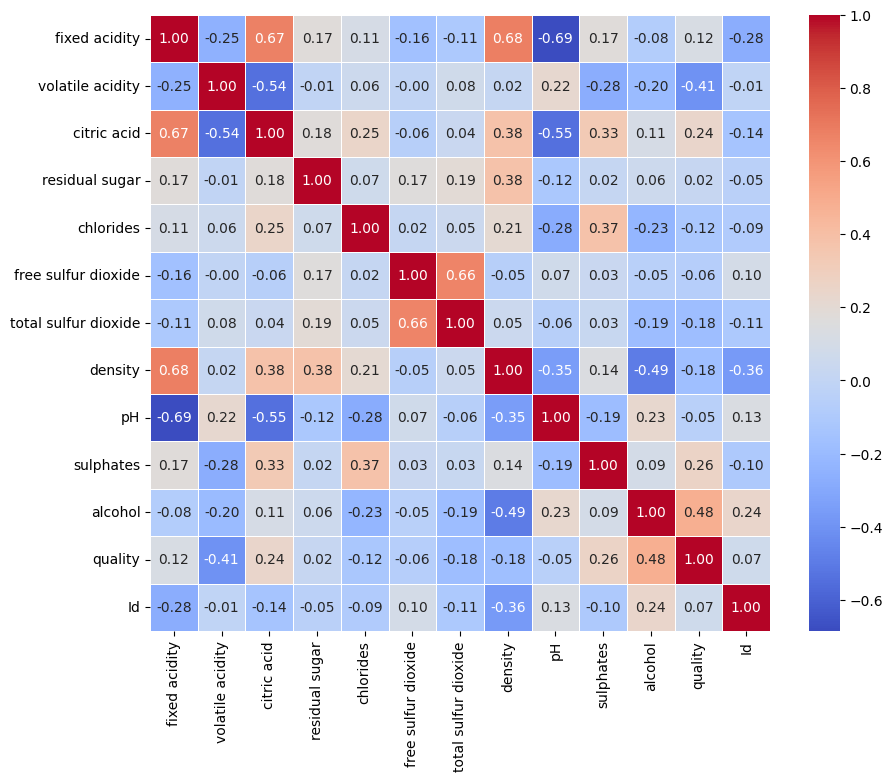

In [2]:
plt.figure(figsize=(10, 8))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

# Clean data and split it training and test

In [3]:
from sklearn.model_selection import train_test_split

df_cleaned = df.drop(columns=['Id'])

X = df_cleaned.drop(columns=['quality'])
y = df_cleaned['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Träningsdata (X_train): {X_train.shape}")
print(f"Testdata (X_test): {X_test.shape}")

Träningsdata (X_train): (914, 11)
Testdata (X_test): (229, 11)


# Träna och jämför modeller regression och random forest 

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train) 

lin_preds = lin_model.predict(X_test)

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train) 

rf_preds = rf_model.predict(X_test)

print("--- Resultat för Linjär Regression ---")
print(f"MSE: {mean_squared_error(y_test, lin_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lin_preds)):.4f}")
print(f"R²-score: {r2_score(y_test, lin_preds):.4f}")

print("\n--- Resultat för Random Forest ---")
print(f"MSE: {mean_squared_error(y_test, rf_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"R²-score: {r2_score(y_test, rf_preds):.4f}")

--- Resultat för Linjär Regression ---
MSE: 0.3800
RMSE: 0.6165
R²-score: 0.3171

--- Resultat för Random Forest ---
MSE: 0.2990
RMSE: 0.5468
R²-score: 0.4628


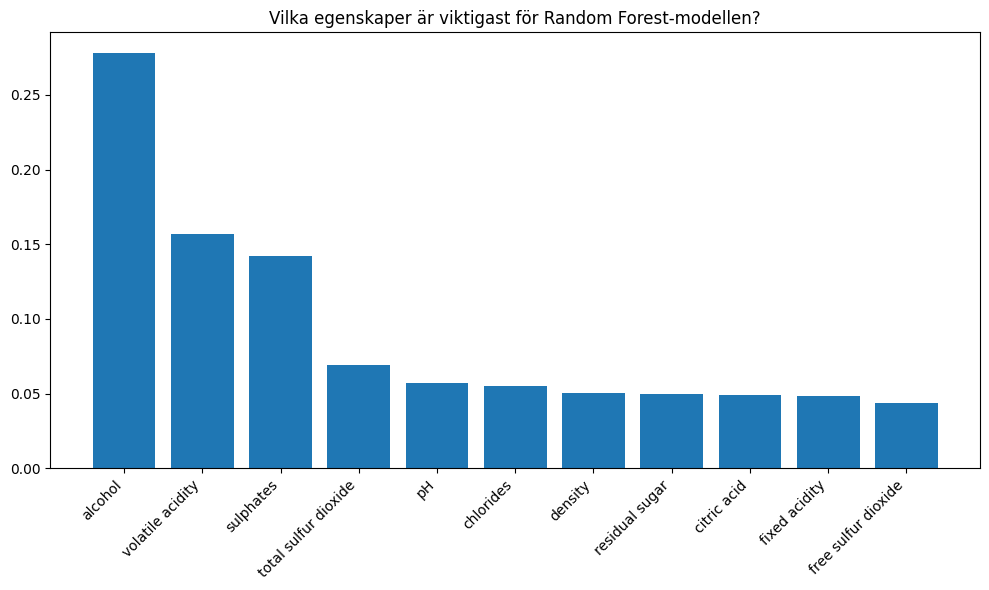

In [5]:
import numpy as np

importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Vilka egenskaper är viktigast för Random Forest-modellen?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()